In [81]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

In [82]:
!wget -nc https://lazyprogrammer.me/course_files/spam.csv

File ‘spam.csv’ already there; not retrieving.



In [83]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')

In [84]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [85]:
df= df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)

In [86]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [87]:
df.columns=['labels','data']

In [88]:
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [89]:
df['b_labels'] = df['labels'].map({'ham':0, 'spam':1})

In [90]:
df.head()

,labels,data,b_labels
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [91]:
df_train,df_test= train_test_split(df,test_size=0.33)

In [92]:
df_train.shape, df_test.shape

((3733, 3), (1839, 3))

In [93]:
idx=1

In [94]:
word2idx={'<PAD>':0}

In [95]:
for i, row in df_train.iterrows():
  tokens= row['data'].lower().split()
  for token in tokens :
    if token not in word2idx:
      word2idx[token]=idx
      idx+=1

In [96]:
len(word2idx)

10475

In [97]:
len(word2idx)

10475

In [98]:
train_sentences_as_int=[]
for i, row in df_train.iterrows():
  tokens= row['data'].lower().split()
  sentence_as_int=[word2idx[token] for token in tokens]
  train_sentences_as_int.append(sentence_as_int)

In [99]:
test_sentences_as_int=[]
for i, row in df_test.iterrows():
  tokens= row['data'].lower().split()
  sentence_as_int=[word2idx[token] for token in tokens if token in word2idx]
  test_sentences_as_int.append(sentence_as_int)

In [100]:
len(train_sentences_as_int), len(test_sentences_as_int)

(3733, 1839)

In [101]:
def data_generator(X, y, batch_size=32):
  X, y = shuffle(X, y)
  n_batches = int(np.ceil(len(y) / batch_size))
  for i in range(n_batches):
    end = min((i +1) * batch_size, len(y))

    X_batch = X[i * batch_size:end]
    y_batch = y[i * batch_size:end]

    # pad X_batch to be N x T
    max_len = np.max([len(x) for x in X_batch])
    for j in range(len(X_batch)):
      x = X_batch[j]
      pad = [0] * (max_len - len(x))
      X_batch[ j] = pad + x

    X_batch = torch.from_numpy(np.array(X_batch)).long()
    y_batch = torch.from_numpy(np.array(y_batch)).long()
    yield X_batch, y_batch

In [102]:
for inputs, targets in data_generator(train_sentences_as_int, df_train.b_labels):
  print("inputs", inputs, "shape:", inputs.shape)
  print("targets", targets, "shape:", targets.shape)
  break

for inputs, targets in data_generator(test_sentences_as_int, df_test.b_labels):
  print("inputs", inputs, "shape:", inputs.shape)
  print("targets", targets, "shape:", targets.shape)
  break

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

inputs tensor([[   0,    0,    0,  ...,  159,   85,  167],
        [   0,    0,    0,  ..., 8750, 1175, 8751],
        [   0,    0,    0,  ..., 2666, 2667,  734],
        ...,
        [   0,    0,    0,  ..., 1391,   58,  529],
        [   0,    0,    0,  ..., 2390, 1276, 2961],
        [   0,    0,    0,  ...,   10, 3959, 3960]]) shape: torch.Size([32, 39])
targets tensor([0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
        0, 0, 0, 0, 1, 0, 0, 1]) shape: torch.Size([32])
inputs tensor([[   0,    0,    0,  ...,   84, 5133, 3284],
        [   0,    0,    0,  ...,  118,  468, 4256],
        [   0,    0,    0,  ..., 7886, 2493, 7054],
        ...,
        [   0,    0,    0,  ...,  967,   98,   86],
        [   0,    0,    0,  ...,  145,   10,  641],
        [   0,    0,    0,  ..., 3874,    7,  707]]) shape: torch.Size([32, 59])
targets tensor([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 0]) shape: torch

In [103]:
class RNN(nn.Module):
  def __init__(self, n_vocab, embed_dim, n_hidden, n_rnnlayers, n_outputs):
    super(RNN, self).__init__()
    self.V = n_vocab
    self.D = embed_dim
    self.M = n_hidden
    self.K = n_outputs
    self.L = n_rnnlayers

    self.embed = nn.Embedding(self.V, self.D)
    self.rnn = nn.LSTM(
      input_size=self.D,
      hidden_size=self.M,
      num_layers=self.L,
      batch_first=True)
    self.fc = nn.Linear(self.M, self.K)

  def forward(self, X):
    # initial hidden states
    h0 = torch.zeros(self.L, X.size(0), self.M).to(device)
    c0 = torch.zeros(self.L, X.size(0), self.M).to(device)

    # embedding layer
    # turns word indexes into word vectors
    out = self.embed(X)

    # get RNN unit output
    out,_ = self.rnn(out, (h0, c0))

    # max pool
    out,_= torch.max(out, 1)

    # we only want h(T) at the final time step
    out= self.fc(out)
    return out

In [104]:
model =RNN(len(word2idx), 20, 15, 1,1)
model.to(device)

RNN(
  (embed): Embedding(10475, 20)
  (rnn): LSTM(20, 15, batch_first=True)
  (fc): Linear(in_features=15, out_features=1, bias=True)
)

In [105]:
# Loss and optimizer
criterion = nn.BCEWithLogitsLoss ()
optimizer = torch.optim.Adam(model.parameters())

In [106]:
train_gen = lambda: data_generator(train_sentences_as_int, df_train.b_labels)
test_gen = lambda: data_generator(test_sentences_as_int, df_test.b_labels)

In [107]:
# A function to encapsulate the training loop
def batch_gd(model, criterion, optimizer, epochs) :
  train_losses = np.zeros (epochs)
  test_losses = np.zeros (epochs)
  train_accuracies = np.zeros(epochs)
  test_accuracies = np.zeros(epochs)

  for it in range(epochs):
    t0 = datetime.now()
    train_loss =[]
    n_train = 0
    n_correct_train = 0
    for inputs, targets in train_gen():
      targets= targets.view(-1,1).float()
      inputs, targets = inputs.to(device), targets.to(device)
      optimizer.zero_grad()
      outputs = model(inputs)
      loss = criterion(outputs, targets)

      # Backward and optimize
      loss.backward()
      optimizer.step()

      train_loss.append(loss.item())
      predictions = (torch.sigmoid(outputs) > 0.5).long()
      n_correct_train += (predictions == targets.long()).sum().item()
      n_train += targets.shape[0]

      # Get train loss and test loss
    train_loss = np.mean(train_loss)
    train_accuracy = n_correct_train / n_train

    test_loss = []
    n_test = 0
    n_correct_test = 0
    for inputs, targets in test_gen():
      inputs, targets = inputs.to(device), targets.to(device)
      targets= targets.view(-1,1).float()
      outputs = model(inputs)
      loss = criterion(outputs, targets)
      test_loss.append(loss.item())
      predictions = (torch.sigmoid(outputs) > 0.5).long()
      n_correct_test += (predictions == targets.long()).sum().item()
      n_test += targets.shape[0]
    test_loss = np.mean(test_loss)
    test_accuracy = n_correct_test / n_test

# Save losses and accuracies
    train_losses[it] = train_loss
    test_losses[it] = test_loss
    train_accuracies[it] = train_accuracy
    test_accuracies[it] = test_accuracy

    dt = datetime.now() - t0
    print(f'Epoch {it+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.4f}, Duration: {dt}' )

  return train_losses, test_losses, train_accuracies, test_accuracies

In [108]:
train_losses, test_losses, train_accuracies, test_accuracies = batch_gd(model, criterion, optimizer, 15)

Epoch 1/15, Train Loss: 0.4698, Train Acc: 0.8610, Test Loss: 0.3897, Test Acc: 0.8635, Duration: 0:00:01.483946
Epoch 2/15, Train Loss: 0.3616, Train Acc: 0.8671, Test Loss: 0.3504, Test Acc: 0.8635, Duration: 0:00:01.436061
Epoch 3/15, Train Loss: 0.2983, Train Acc: 0.8690, Test Loss: 0.2841, Test Acc: 0.8668, Duration: 0:00:01.740157
Epoch 4/15, Train Loss: 0.2186, Train Acc: 0.9022, Test Loss: 0.2112, Test Acc: 0.9407, Duration: 0:00:01.589089
Epoch 5/15, Train Loss: 0.1534, Train Acc: 0.9587, Test Loss: 0.1741, Test Acc: 0.9511, Duration: 0:00:01.360026
Epoch 6/15, Train Loss: 0.1130, Train Acc: 0.9703, Test Loss: 0.1543, Test Acc: 0.9532, Duration: 0:00:01.380060
Epoch 7/15, Train Loss: 0.0898, Train Acc: 0.9756, Test Loss: 0.1423, Test Acc: 0.9598, Duration: 0:00:01.406383
Epoch 8/15, Train Loss: 0.0698, Train Acc: 0.9831, Test Loss: 0.1404, Test Acc: 0.9641, Duration: 0:00:01.373380
Epoch 9/15, Train Loss: 0.0606, Train Acc: 0.9845, Test Loss: 0.1381, Test Acc: 0.9608, Duration

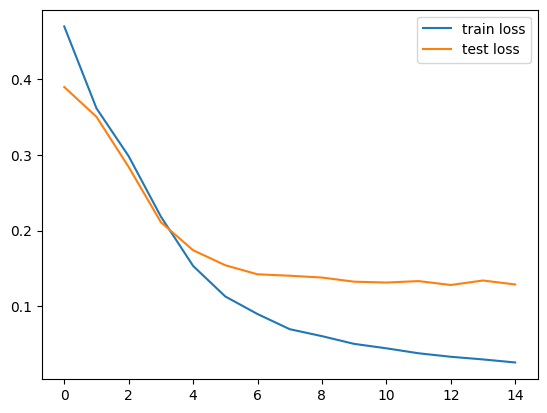

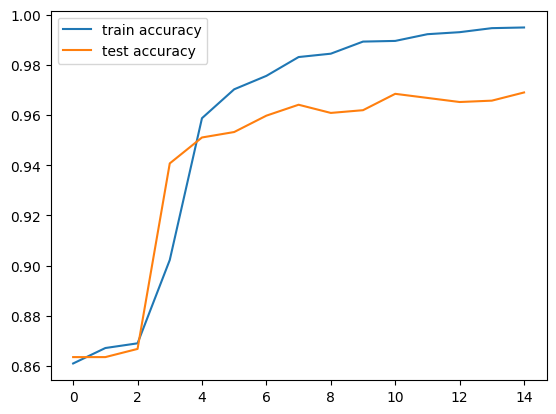

In [109]:
# Plot the train loss and test loss per iteration
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()
plt.show()

# Plot the train accuracy and test accuracy per iteration
plt.plot(train_accuracies, label='train accuracy')
plt.plot(test_accuracies, label='test accuracy')
plt.legend()
plt.show()

In [110]:
# Accuracy

n_correct = 0.
n_total = 0.
for inputs, targets in train_gen():
  targets = targets.view(-1, 1).float()
  inputs, targets = inputs.to(device), targets.to(device)

  # Forward pass
  outputs = model(inputs)

  # Get prediction
  predictions = (outputs > 0)

  # update counts
  n_correct += (predictions == targets).sum().item()
  n_total += targets.shape[0]

train_acc = n_correct / n_total

n_correct_test = 0.
n_total_test = 0.
for inputs, targets in test_gen():
  targets = targets.view(-1, 1).float()
  inputs, targets = inputs.to(device), targets.to(device)

  # Forward pass
  outputs = model(inputs)

  # Get prediction
  predictions = (outputs > 0)

  # update counts
  n_correct_test += (predictions == targets).sum().item()
  n_total_test += targets.shape[0]

test_acc = n_correct_test / n_total_test

print(f'Train acc: {train_acc:.4f},Test acc:{test_acc:.4f}')

Train acc: 0.9954,Test acc:0.9695
